# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## Task 1.1: Nasdaq Multi-Feature Extension

This section implements stock price prediction using multiple features (Low, High, Open, Close, Adjusted Close, Volume) instead of relying solely on the Open price. The model uses a 30-day sliding window to predict the next day's Open price.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [30]:
data_appl = pd.read_csv('AAPL.csv')

In [31]:
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [32]:
# Get some info about the data
data_appl.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 579.3 KB


In [33]:
df = data_appl
feature_columns = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
num_features = len(feature_columns)

X_data = []
y_data = []
window_size = 30

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df[feature_columns].iloc[i + j].values)

    data_label.append(df['Open'].iloc[i + window_size])

    X_data.append(np.array(data_feature))
    y_data.append(np.array(data_label))


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Shape of training set: ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ", X_test.shape)
print("Number of features: ", X_train.shape[2])

Shape of training set:  (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:  (2112, 30, 6)
Number of features:  6


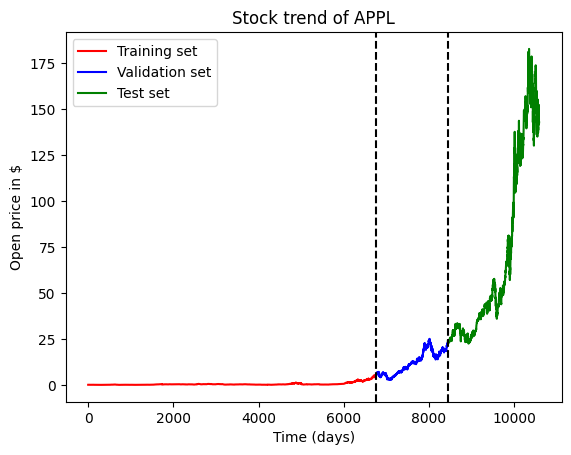

In [35]:
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

size_train = X_train.shape[0]
size_val = X_val.shape[0]
size_test = X_test.shape[0]

ax = df_plot.iloc[:size_train,1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [36]:
def normalize_multifeature(X, y):
    """MinMax normalize X per feature per sample. Normalize y using Open price stats."""
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):  # for each feature column
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        # Normalize label (Open price) using Open column (index 1) stats
        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

X_train_norm, y_train_norm = normalize_multifeature(X_train, y_train)

X_val_norm, y_val_norm = normalize_multifeature(X_val, y_val)

In [37]:
model = tf.keras.Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.2785 - mse: 2.2785 - val_loss: 0.1548 - val_mse: 0.1548
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1560 - mse: 0.1560 - val_loss: 0.1450 - val_mse: 0.1450
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1283 - mse: 0.1283 - val_loss: 0.0953 - val_mse: 0.0953
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0927 - mse: 0.0927 - val_loss: 0.0874 - val_mse: 0.0874
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0794 - mse: 0.0794 - val_loss: 0.0770 - val_mse: 0.0770


In [38]:
X_test_norm, y_test_norm = normalize_multifeature(X_test, y_test)

In [39]:
y_pred_norm = model.predict(X_test_norm)
print("MSE on the test set: ", mean_squared_error(y_pred_norm, y_test_norm))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE on the test set:  0.07685057026030162


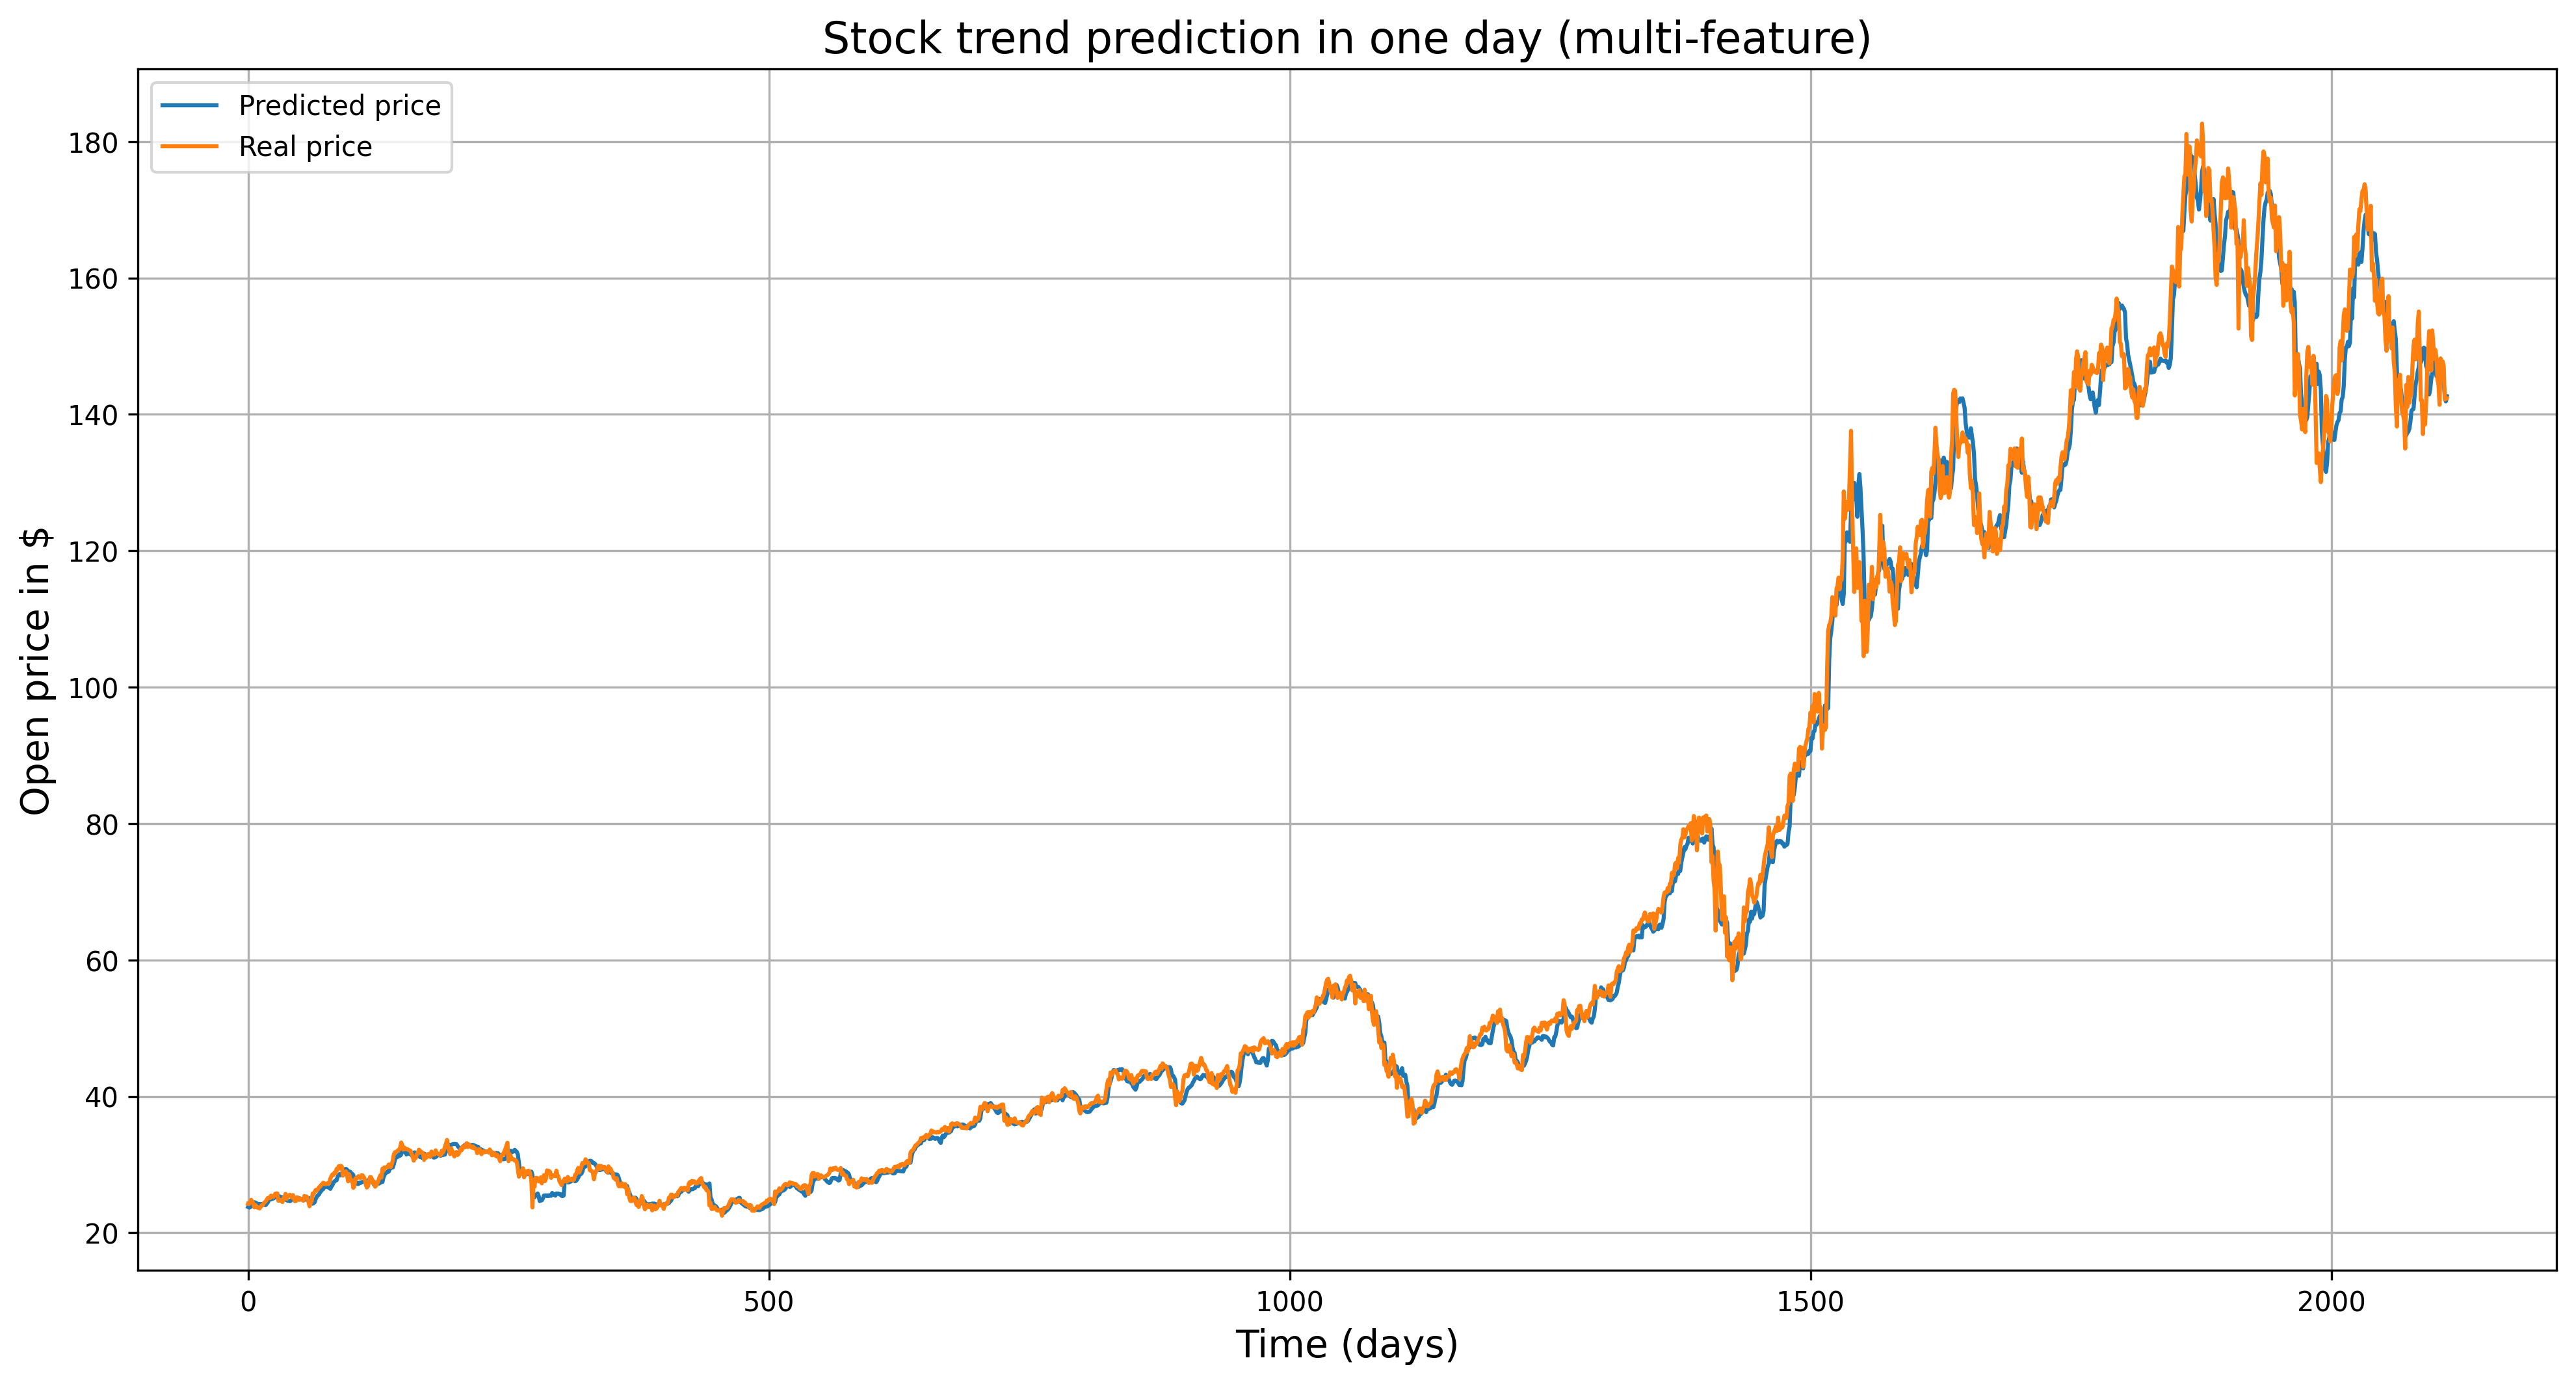

In [40]:
y_pred_denorm = y_pred_norm.copy()
for i in range(0, len(y_pred_denorm)):
    open_min = np.min(X_test[i, :, 1])
    open_max = np.max(X_test[i, :, 1])
    y_pred_denorm[i] = y_pred_norm[i] * (open_max - open_min) + open_min

# Visualize predicted stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm, label='Predicted price')
plt.plot(y_test, label='Real price')
plt.title('Stock trend prediction in one day (multi-feature)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid() # Add grid
plt.legend() # Add legend
plt.show()

## Task 1.2: Nasdaq k-th Day Forecast

This section implements the k-th day forecast, predicting the stock price on the k-th day ahead instead of just the next day.

In [41]:
def prepare_data_k(df, feature_columns, window_size, k):
    """Prepare data for k-day ahead prediction."""
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        # Predict the Open price k days ahead
        data_label.append(df['Open'].iloc[i + window_size + k - 1])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)


In [42]:
k_values = [3, 5, 7]
results = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Training model for k={k} day ahead prediction")
    print('='*50)
    
    # Prepare data for k-day ahead
    X_k, y_k = prepare_data_k(df, feature_columns, window_size, k)
    
    # Split data
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, shuffle=False)
    X_train_k, X_val_k, y_train_k, y_val_k = train_test_split(X_train_k, y_train_k, test_size=0.2, shuffle=False)
    
    print(f"Training set: {X_train_k.shape[0]}, Val: {X_val_k.shape[0]}, Test: {X_test_k.shape[0]}")
    
    # Normalize data
    X_train_norm_k, y_train_norm_k = normalize_multifeature(X_train_k, y_train_k)
    X_val_norm_k, y_val_norm_k = normalize_multifeature(X_val_k, y_val_k)
    X_test_norm_k, y_test_norm_k = normalize_multifeature(X_test_k, y_test_k)
    
    # Build and train model
    model_k = tf.keras.Sequential()
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
    model_k.add(MaxPooling1D(pool_size=2))
    model_k.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Flatten())
    model_k.add(Dense(100, activation='relu'))
    model_k.add(Dense(1))
    
    model_k.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
    history_k = model_k.fit(X_train_norm_k, y_train_norm_k, validation_data=(X_val_norm_k, y_val_norm_k), epochs=5, batch_size=512, verbose=1)
    
    # Evaluate on test set
    y_pred_norm_k = model_k.predict(X_test_norm_k)
    mse_k = mean_squared_error(y_pred_norm_k, y_test_norm_k)
    
    # Denormalize predictions for visualization
    y_pred_denorm_k = y_pred_norm_k.copy()
    for i in range(len(y_pred_denorm_k)):
        open_min = np.min(X_test_k[i, :, 1])
        open_max = np.max(X_test_k[i, :, 1])
        y_pred_denorm_k[i] = y_pred_norm_k[i] * (open_max - open_min) + open_min
    
    results[k] = {
        'mse_norm': mse_k,
        'y_pred_denorm': y_pred_denorm_k,
        'y_test': y_test_k,
        'model': model_k,
        'history': history_k
    }
    
    print(f"MSE on test set (k={k}): {mse_k}")



Training model for k=3 day ahead prediction
Training set: 6755, Val: 1689, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.1518 - mse: 1.1518 - val_loss: 0.2716 - val_mse: 0.2716
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2261 - mse: 0.2261 - val_loss: 0.1975 - val_mse: 0.1975
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1774 - mse: 0.1774 - val_loss: 0.1330 - val_mse: 0.1330
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1417 - mse: 0.1417 - val_loss: 0.1301 - val_mse: 0.1301
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1280 - mse: 0.1280 - val_loss: 0.1035 - val_mse: 0.1035
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE on test set (k=3): 0.10724661061687231

Training model for k=5 day ahead prediction
Training set: 6754, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.9326 - mse: 1.9326 - val_loss: 0.2570 - val_mse: 0.2570
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2703 - mse: 0.2703 - val_loss: 0.1801 - val_mse: 0.1801
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1647 - mse: 0.1647 - val_loss: 0.1240 - val_mse: 0.1240
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1373 - mse: 0.1373 - val_loss: 0.1120 - val_mse: 0.1120
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1329 - mse: 0.1329 - val_loss: 0.1106 - val_mse: 0.1106
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=5): 0.1110348668851054

Training model for k=7 day ahead prediction
Training set: 6752, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.3219 - mse: 1.3219 - val_loss: 0.3670 - val_mse: 0.3670
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3422 - mse: 0.3422 - val_loss: 0.2519 - val_mse: 0.2519
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2865 - mse: 0.2865 - val_loss: 0.2155 - val_mse: 0.2155
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2442 - mse: 0.2442 - val_loss: 0.1805 - val_mse: 0.1805
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2142 - mse: 0.2142 - val_loss: 0.1733 - val_mse: 0.1733
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=7): 0.1800550888733699


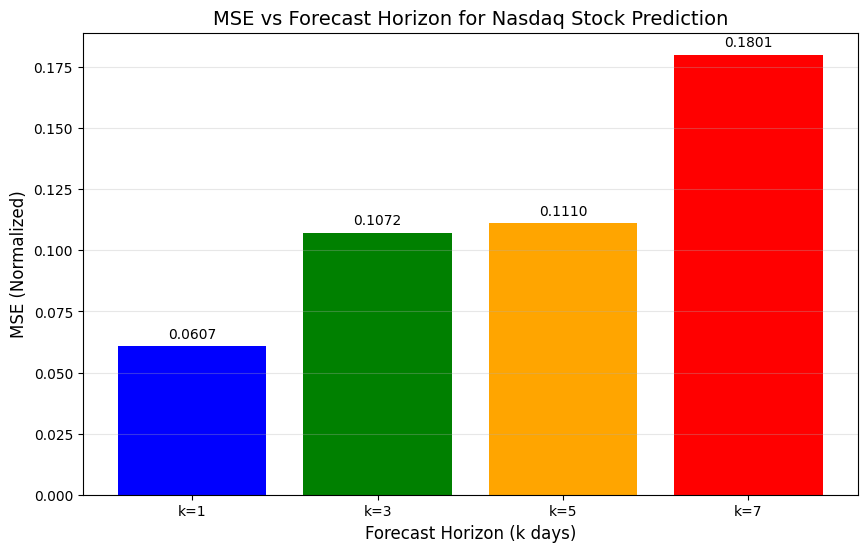


=== Task 1.2 Summary: k-th Day Forecast ===
k=1: MSE = 0.060663
k=3: MSE = 0.107247
k=5: MSE = 0.111035
k=7: MSE = 0.180055


In [43]:
# MSE comparison across different forecast horizons
# k=1 result from previous cell
k1_mse = 0.06066341114596852
all_k = [1, 3, 5, 7]
all_mse = [k1_mse] + [results[k]['mse_norm'] for k in [3, 5, 7]]

plt.figure(figsize=(10, 6))
bars = plt.bar([f'k={k}' for k in all_k], all_mse, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Forecast Horizon (k days)', fontsize=12)
plt.ylabel('MSE (Normalized)', fontsize=12)
plt.title('MSE vs Forecast Horizon for Nasdaq Stock Prediction', fontsize=14)
plt.grid(axis='y', alpha=0.3)
for bar, mse in zip(bars, all_mse):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{mse:.4f}', ha='center', va='bottom', fontsize=10)
plt.show()

# Print summary
print("\n=== Task 1.2 Summary: k-th Day Forecast ===")
for k, mse in zip(all_k, all_mse):
    print(f"k={k}: MSE = {mse:.6f}")


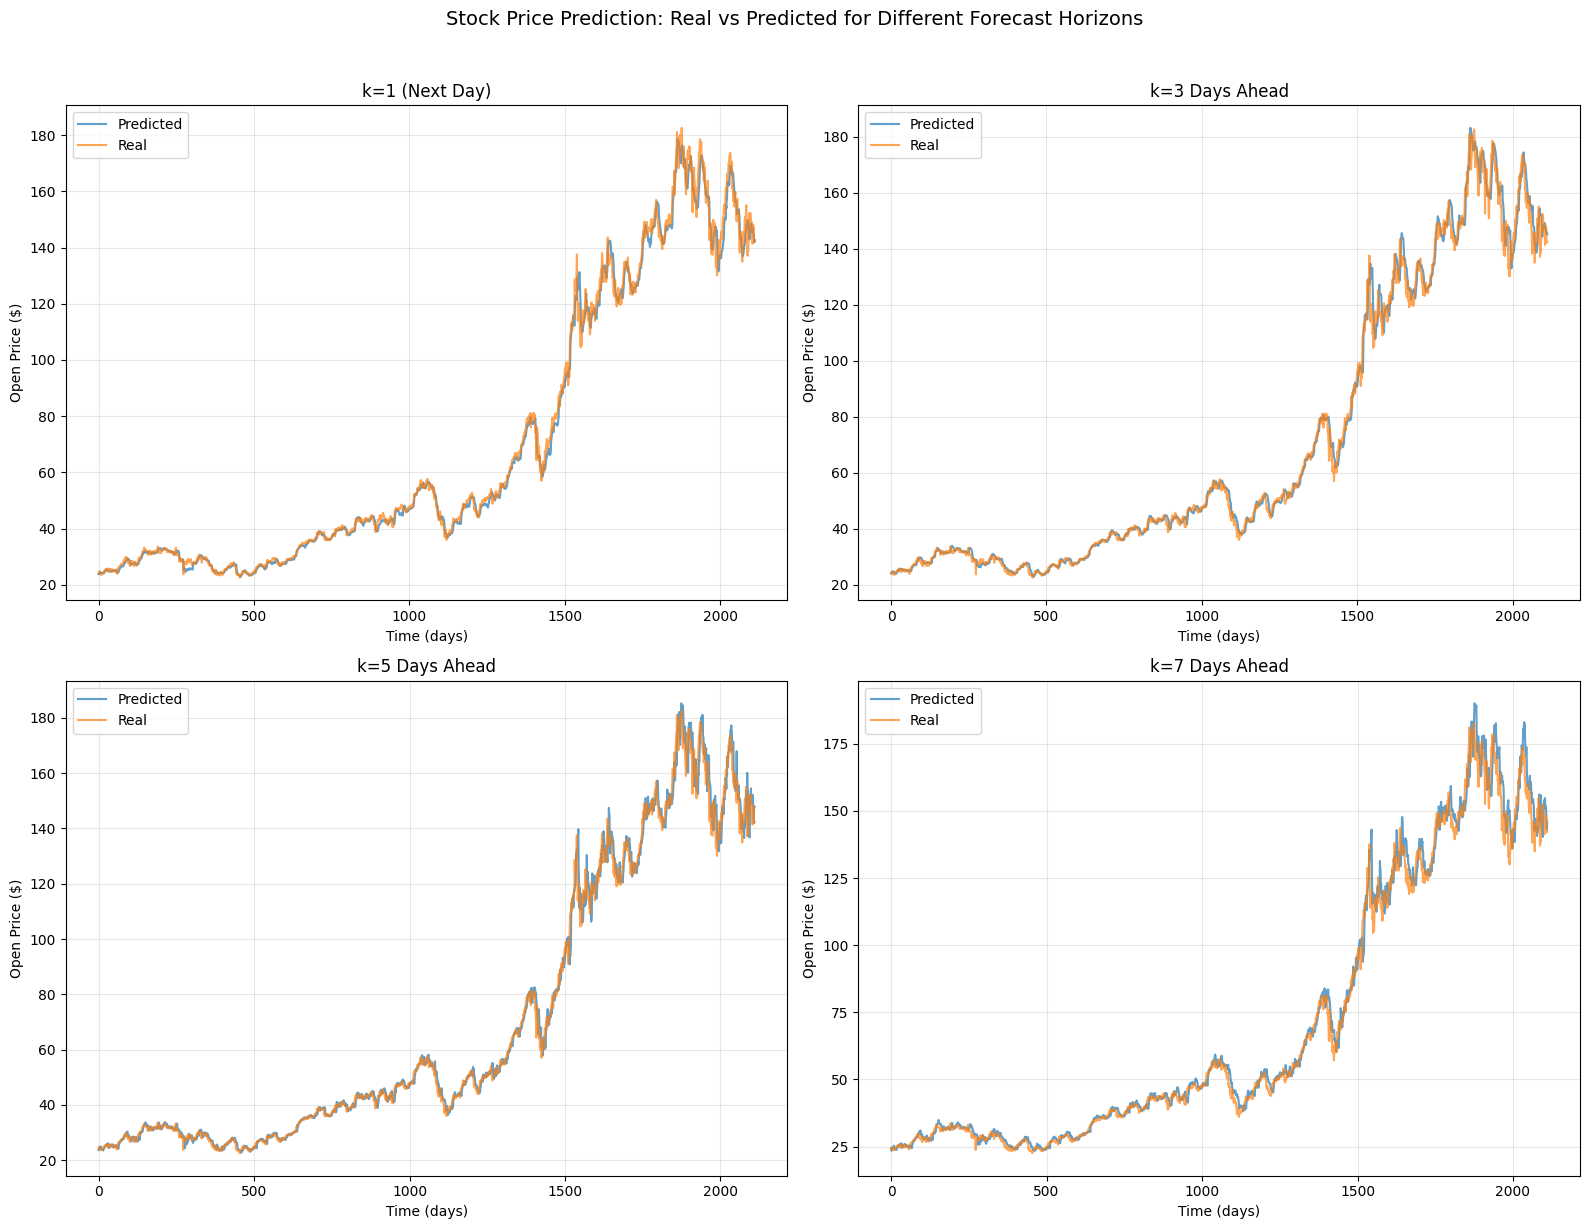

In [44]:
# Visualize predicted vs real stock prices for each k
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# k=1 (from previous model)
axes[0, 0].plot(y_pred_denorm, label='Predicted', alpha=0.7)
axes[0, 0].plot(y_test, label='Real', alpha=0.7)
axes[0, 0].set_title('k=1 (Next Day)', fontsize=12)
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Open Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# k=3, 5, 7
for idx, k in enumerate([3, 5, 7]):
    row = (idx + 1) // 2
    col = (idx + 1) % 2
    axes[row, col].plot(results[k]['y_pred_denorm'], label='Predicted', alpha=0.7)
    axes[row, col].plot(results[k]['y_test'], label='Real', alpha=0.7)
    axes[row, col].set_title(f'k={k} Days Ahead', fontsize=12)
    axes[row, col].set_xlabel('Time (days)')
    axes[row, col].set_ylabel('Open Price ($)')
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.suptitle('Stock Price Prediction: Real vs Predicted for Different Forecast Horizons', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
